In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report,confusion_matrix, ConfusionMatrixDisplay,roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [213]:
df=pd.read_csv("Dataset_Online _Purchase_Prediction.csv")
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,264.000,100,71,3,44.0,85.312,0.646,1,1
1,40.481,4,14,1,6.0,86.301,0.729,1,1
2,2.528,14,8,3,4.0,NaN,0.189,1,1
3,37.377,6,8,5,3.0,38.793,0.400,1,1
4,21.628,4,9,3,1.0,57.570,0.760,1,1
...,...,...,...,...,...,...,...,...,...
995,24.345,3,14,0,5.0,135.490,0.486,1,1
996,27.257,2,11,3,2.0,104.719,0.766,1,1
997,6.647,6,7,1,1.0,101.711,0.468,0,1
998,30.765,6,9,2,3.0,146.399,0.294,0,1


In [214]:
df.describe()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
count,970.000000,1000.000000,1000.000000,1000.000000,970.000000,970.000000,1000.000000,1000.00000,1000.000000
mean,30.966446,7.586000,11.555000,2.162000,3.639175,72.576936,0.516615,0.60200,0.909000
std,39.648443,12.404373,11.461516,1.931188,5.086427,38.622832,0.239605,0.48973,0.287753
min,1.000000,0.000000,1.000000,0.000000,0.000000,5.000000,0.100000,0.00000,0.000000
25%,17.294500,4.000000,8.000000,1.000000,2.000000,50.382250,0.298000,0.00000,1.000000
50%,26.608500,6.000000,10.000000,2.000000,3.000000,70.181500,0.521000,1.00000,1.000000
75%,33.995750,7.000000,12.000000,3.000000,4.000000,90.614250,0.732500,1.00000,1.000000
max,398.000000,142.000000,116.000000,19.000000,49.000000,392.000000,0.996000,1.00000,1.000000


In [215]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()

Shape: (1000, 9)

Columns:
 Index(['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate',
       'Discount_Viewed', 'Purchase'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Browsing_Time         970 non-null    float64
 1   Clicks                1000 non-null   int64  
 2   Product_Views         1000 non-null   int64  
 3   Cart_Additions        1000 non-null   int64  
 4   Previous_Purchases    970 non-null    float64
 5   Time_on_Product_Page  970 non-null    float64
 6   Bounce_Rate           1000 non-null   float64
 7   Discount_Viewed       1000 non-null   int64  
 8   Purchase              1000 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 70.4 KB


In [216]:
df.head()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,264.000,100,71,3,44.0,85.312,0.646,1,1
1,40.481,4,14,1,6.0,86.301,0.729,1,1
2,2.528,14,8,3,4.0,NaN,0.189,1,1
3,37.377,6,8,5,3.0,38.793,0.400,1,1
4,21.628,4,9,3,1.0,57.570,0.760,1,1


In [217]:
df.tail()

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
995,24.345,3,14,0,5.0,135.490,0.486,1,1
996,27.257,2,11,3,2.0,104.719,0.766,1,1
997,6.647,6,7,1,1.0,101.711,0.468,0,1
998,30.765,6,9,2,3.0,146.399,0.294,0,1
999,4.649,4,19,3,3.0,61.918,0.375,0,1


In [218]:
df.isnull().sum()

Browsing_Time           30
Clicks                   0
Product_Views            0
Cart_Additions           0
Previous_Purchases      30
Time_on_Product_Page    30
Bounce_Rate              0
Discount_Viewed          0
Purchase                 0
dtype: int64

In [219]:
df["Browsing_Time"] = df["Browsing_Time"].fillna(df["Browsing_Time"].mean())
df["Previous_Purchases"]=df["Previous_Purchases"].fillna(df["Previous_Purchases"].mean())
df["Time_on_Product_Page"]=df["Time_on_Product_Page"].fillna(df["Time_on_Product_Page"].mean())

In [220]:
df.isnull().sum()

Browsing_Time           0
Clicks                  0
Product_Views           0
Cart_Additions          0
Previous_Purchases      0
Time_on_Product_Page    0
Bounce_Rate             0
Discount_Viewed         0
Purchase                0
dtype: int64

In [221]:
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
0,264.000,100,71,3,44.0,85.312000,0.646,1,1
1,40.481,4,14,1,6.0,86.301000,0.729,1,1
2,2.528,14,8,3,4.0,72.576936,0.189,1,1
3,37.377,6,8,5,3.0,38.793000,0.400,1,1
4,21.628,4,9,3,1.0,57.570000,0.760,1,1
...,...,...,...,...,...,...,...,...,...
995,24.345,3,14,0,5.0,135.490000,0.486,1,1
996,27.257,2,11,3,2.0,104.719000,0.766,1,1
997,6.647,6,7,1,1.0,101.711000,0.468,0,1
998,30.765,6,9,2,3.0,146.399000,0.294,0,1


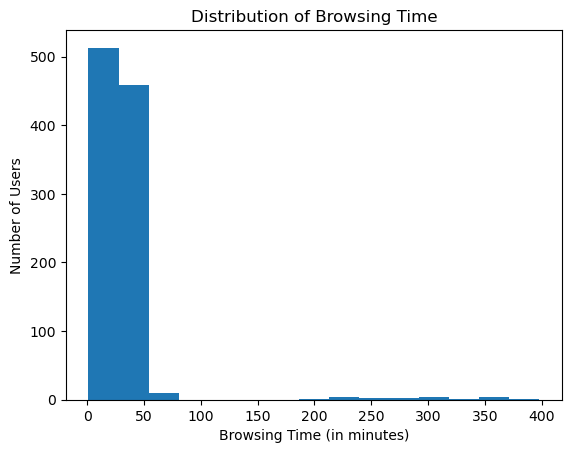

In [222]:
plt.figure()
plt.hist(df["Browsing_Time"], bins=15)
plt.xlabel("Browsing Time (in minutes)")   
plt.ylabel("Number of Users")              
plt.title("Distribution of Browsing Time")
plt.show()

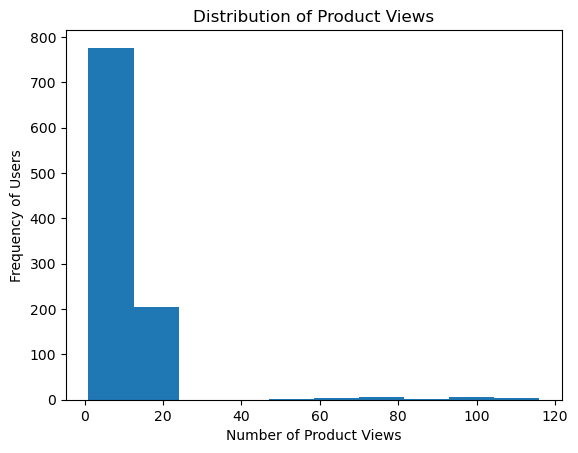

In [223]:
plt.figure()
plt.hist(df["Product_Views"], bins=10)
plt.xlabel("Number of Product Views")
plt.ylabel("Frequency of Users")
plt.title("Distribution of Product Views")
plt.show()

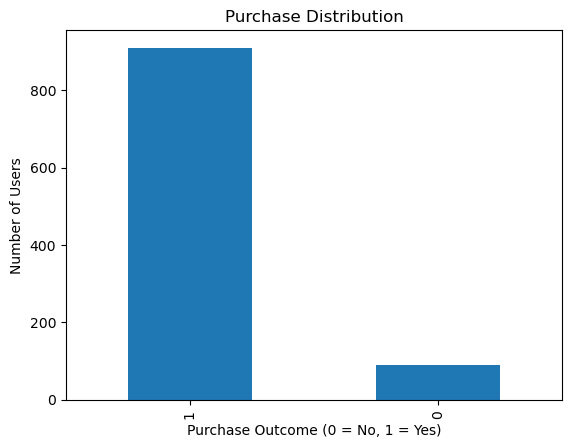

In [224]:
plt.figure()
df["Purchase"].value_counts().plot(kind="bar")
plt.xlabel("Purchase Outcome (0 = No, 1 = Yes)")
plt.ylabel("Number of Users")
plt.title("Purchase Distribution")
plt.show()

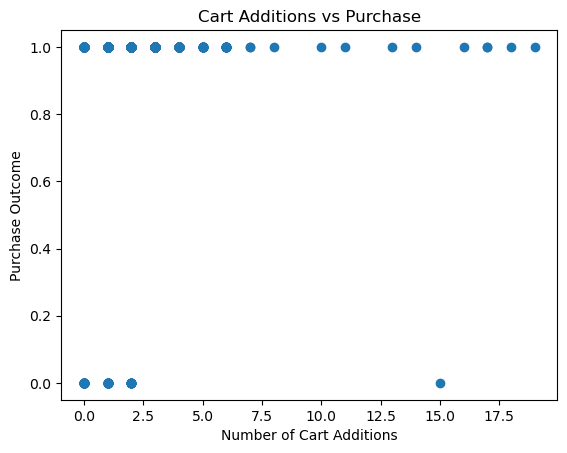

In [225]:
plt.figure()
plt.scatter(df["Cart_Additions"], df["Purchase"])
plt.xlabel("Number of Cart Additions")
plt.ylabel("Purchase Outcome")
plt.title("Cart Additions vs Purchase")
plt.show()

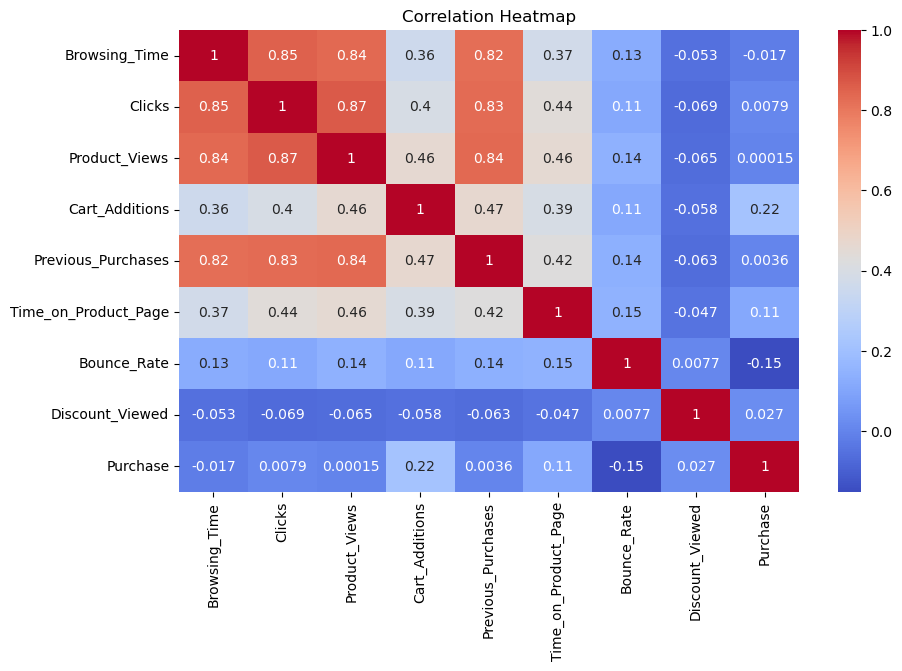

In [226]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

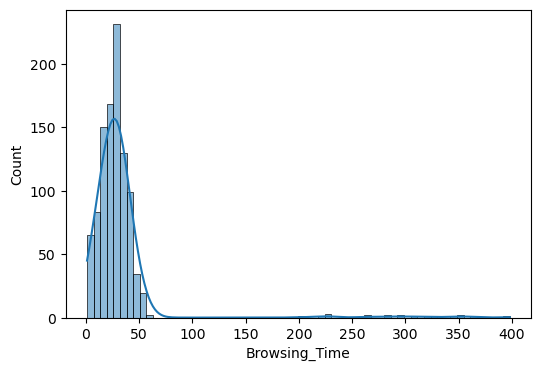

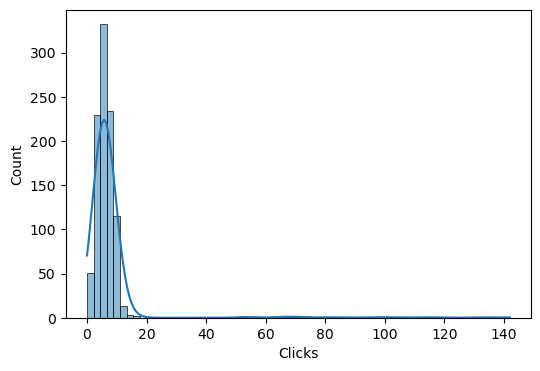

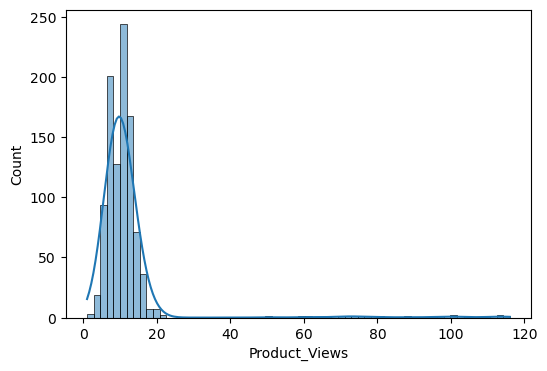

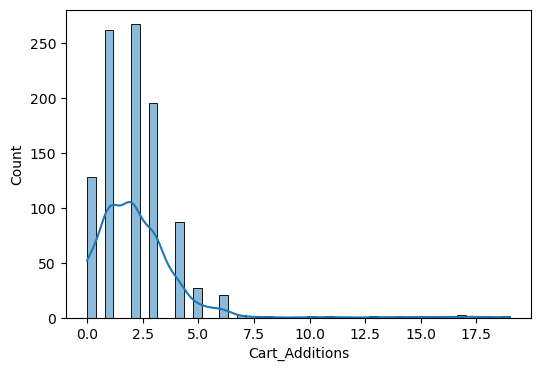

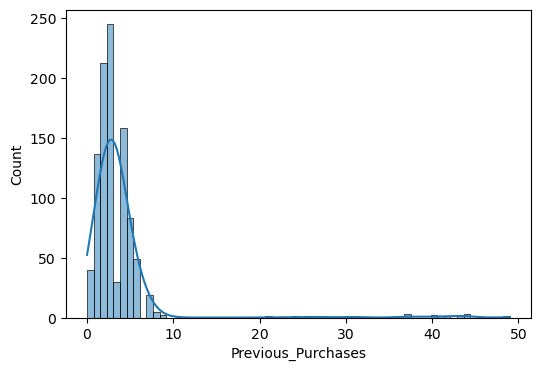

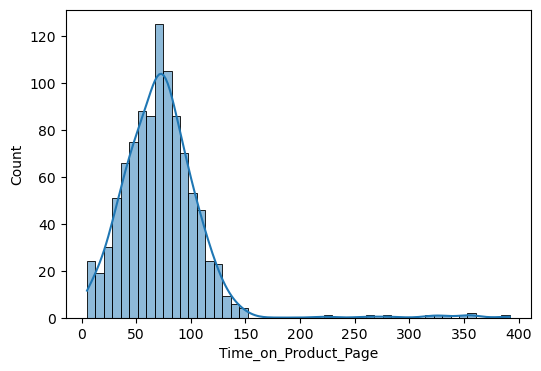

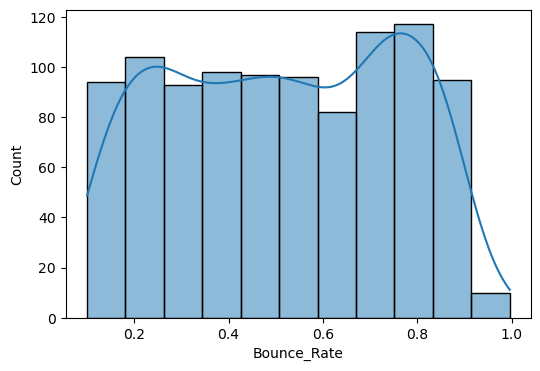

In [227]:
numeric_columns=['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

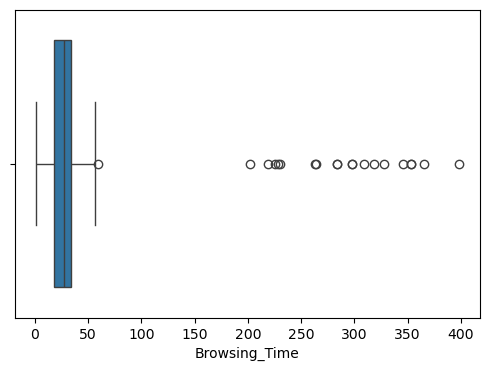

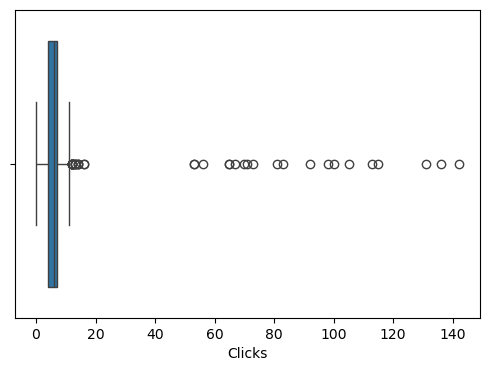

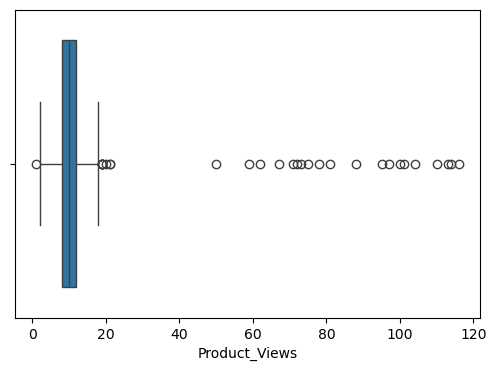

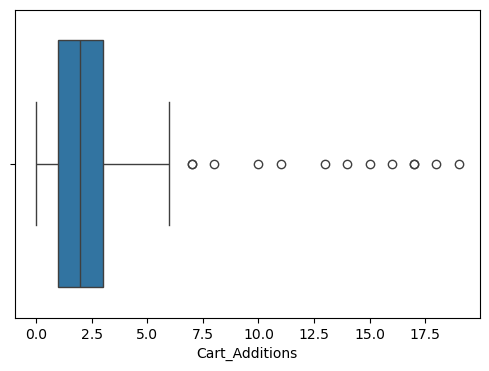

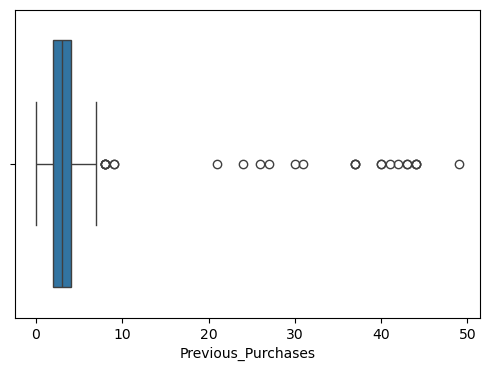

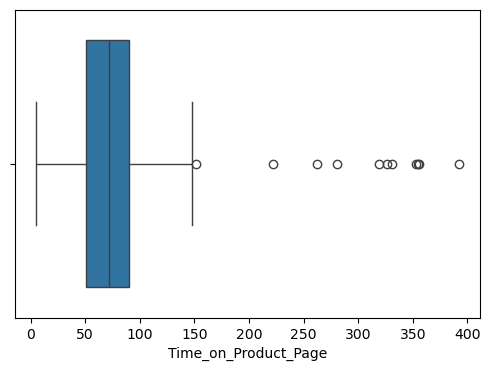

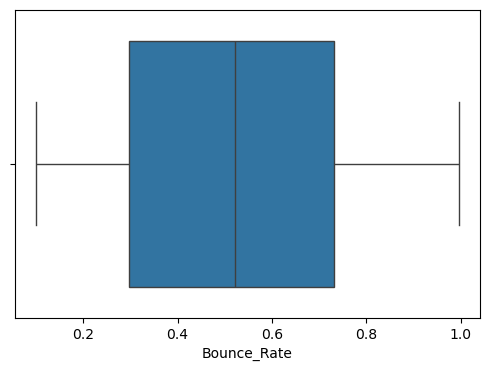

In [228]:
numeric_columns=['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

In [229]:
# Loop through all columns except target
for col in df.columns[:-1]:   # excluding 'Purchase'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 20
Clicks -> Number of Outliers: 38
Product_Views -> Number of Outliers: 30
Cart_Additions -> Number of Outliers: 13
Previous_Purchases -> Number of Outliers: 26
Time_on_Product_Page -> Number of Outliers: 11
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


In [230]:
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print("Outliers removed")

Outliers removed


In [231]:
for col in df.columns[:-1]:  
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 0
Clicks -> Number of Outliers: 0
Product_Views -> Number of Outliers: 0
Cart_Additions -> Number of Outliers: 0
Previous_Purchases -> Number of Outliers: 0
Time_on_Product_Page -> Number of Outliers: 0
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


In [232]:
cols_to_scale = ["Browsing_Time","Clicks","Product_Views","Cart_Additions","Previous_Purchases","Time_on_Product_Page","Bounce_Rate"]
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df

,Browsing_Time,Clicks,Product_Views,Cart_Additions,Previous_Purchases,Time_on_Product_Page,Bounce_Rate,Discount_Viewed,Purchase
1,1.235563,-0.845289,1.360364,-0.737662,1.941653,0.577981,0.912520,1,1
3,0.971127,0.086315,-0.666154,2.160516,0.021204,-1.098010,-0.478906,1,1
4,-0.370562,-0.845289,-0.328401,0.711427,-1.259095,-0.435593,1.043627,1,1
5,1.278670,-1.311091,0.684858,0.711427,0.661354,0.274378,0.967500,0,1
6,1.658882,-0.845289,0.009352,-0.013117,-0.618946,1.149063,-1.570054,1,1
...,...,...,...,...,...,...,...,...,...
994,-0.151022,-1.311091,-2.017165,1.435971,0.661354,0.649278,-1.692703,1,1
995,-0.139095,-1.311091,1.360364,-1.462206,1.301503,2.313275,-0.115190,1,1
996,0.108984,-1.776893,0.347105,0.711427,-0.618946,1.227733,1.069002,1,1
997,-1.646823,0.086315,-1.003907,-0.737662,-1.259095,1.121617,-0.191316,0,1


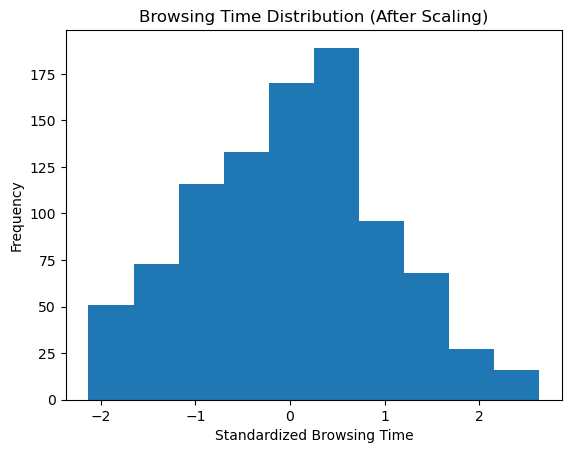

In [233]:
plt.hist(df["Browsing_Time"], bins=10)
plt.xlabel("Standardized Browsing Time")
plt.ylabel("Frequency")
plt.title("Browsing Time Distribution (After Scaling)")
plt.show()

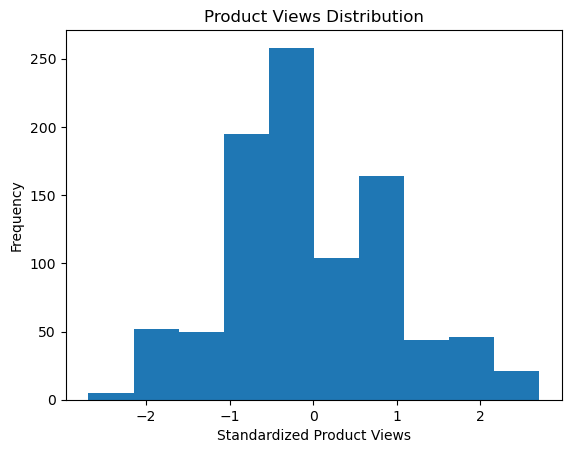

In [234]:
plt.hist(df["Product_Views"], bins=10)
plt.xlabel("Standardized Product Views")
plt.ylabel("Frequency")
plt.title("Product Views Distribution")
plt.show()

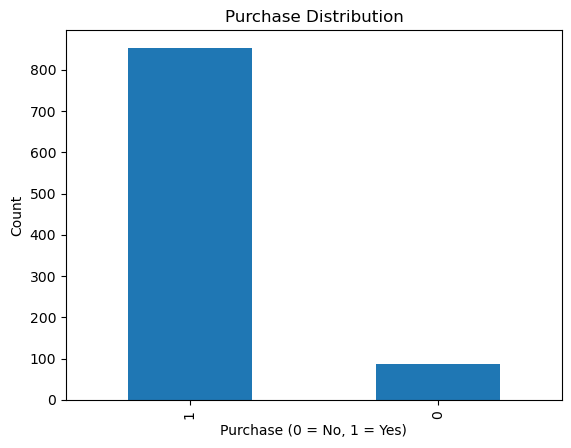

In [235]:
df["Purchase"].value_counts().plot(kind="bar")
plt.xlabel("Purchase (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Purchase Distribution")
plt.show()

In [236]:
for col in df.columns[:-1]:   # excluding 'Purchase'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 0
Clicks -> Number of Outliers: 0
Product_Views -> Number of Outliers: 0
Cart_Additions -> Number of Outliers: 20
Previous_Purchases -> Number of Outliers: 0
Time_on_Product_Page -> Number of Outliers: 0
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


In [237]:
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print("Outliers removed")

Outliers removed


In [238]:
for col in df.columns[:-1]:   # excluding 'Purchase'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} -> Number of Outliers: {outliers.shape[0]}")

Browsing_Time -> Number of Outliers: 1
Clicks -> Number of Outliers: 0
Product_Views -> Number of Outliers: 0
Cart_Additions -> Number of Outliers: 0
Previous_Purchases -> Number of Outliers: 0
Time_on_Product_Page -> Number of Outliers: 0
Bounce_Rate -> Number of Outliers: 0
Discount_Viewed -> Number of Outliers: 0


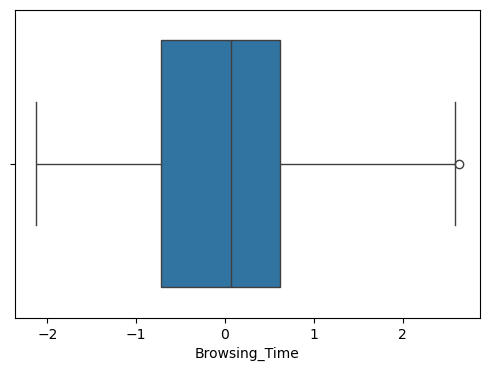

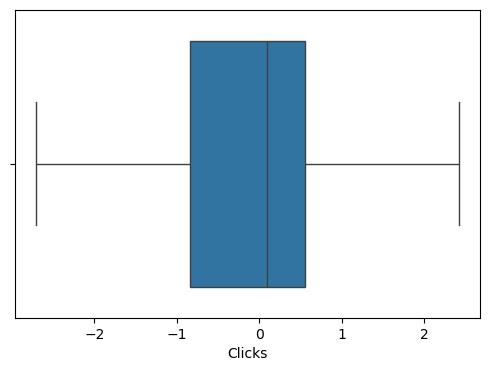

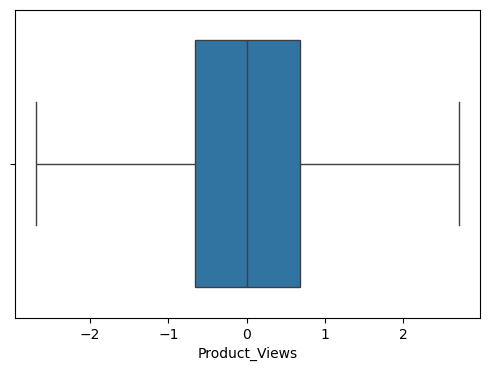

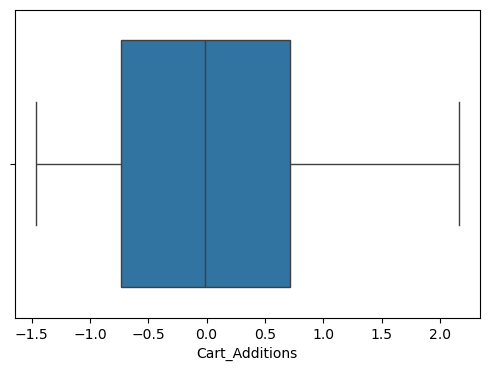

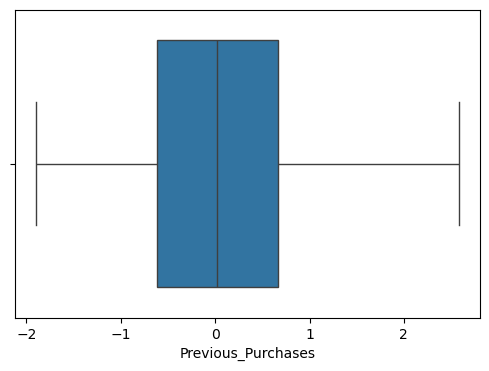

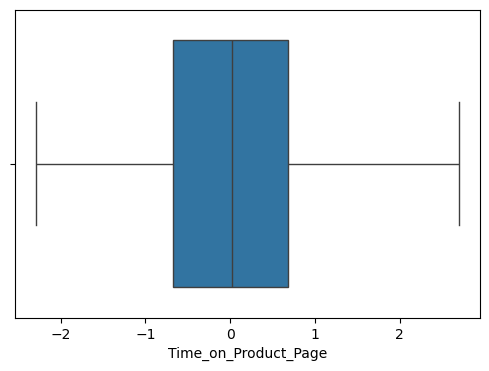

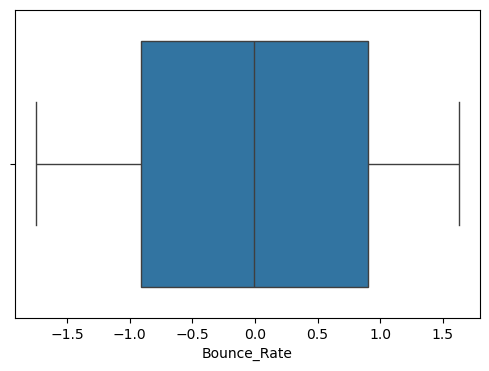

In [239]:
numeric_columns=['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions',
       'Previous_Purchases', 'Time_on_Product_Page', 'Bounce_Rate']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

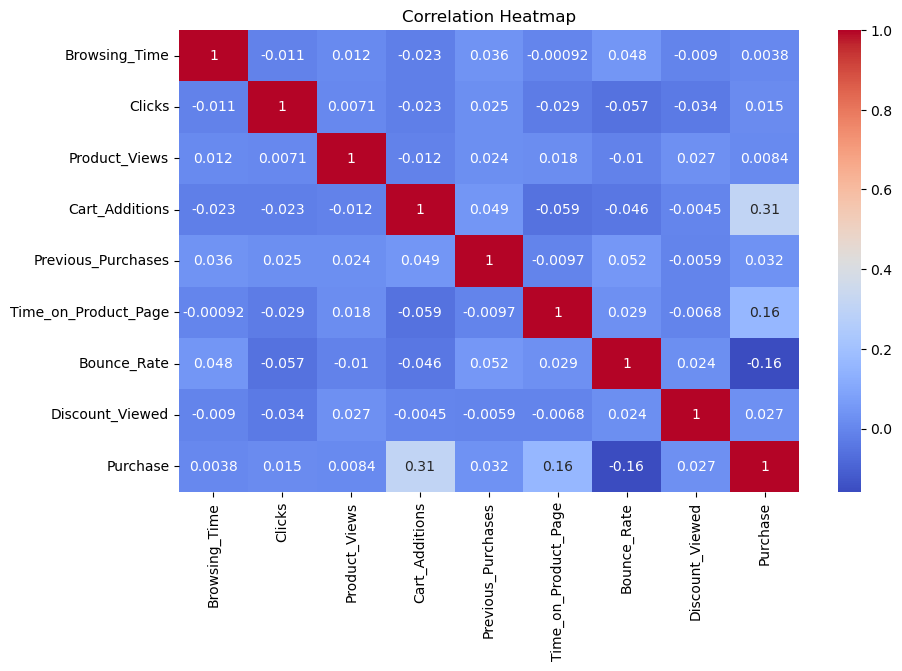

In [240]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [241]:
corr = df.corr()
print(corr)

                      Browsing_Time    Clicks  Product_Views  Cart_Additions  \
Browsing_Time              1.000000 -0.010784       0.011620       -0.022759   
Clicks                    -0.010784  1.000000       0.007075       -0.022821   
Product_Views              0.011620  0.007075       1.000000       -0.011700   
Cart_Additions            -0.022759 -0.022821      -0.011700        1.000000   
Previous_Purchases         0.036452  0.025361       0.024002        0.048651   
Time_on_Product_Page      -0.000920 -0.028650       0.018183       -0.058519   
Bounce_Rate                0.047893 -0.056916      -0.010143       -0.045669   
Discount_Viewed           -0.008970 -0.033657       0.027361       -0.004493   
Purchase                   0.003763  0.015328       0.008358        0.311054   

                      Previous_Purchases  Time_on_Product_Page  Bounce_Rate  \
Browsing_Time                   0.036452             -0.000920     0.047893   
Clicks                          0.025361 

In [242]:
print(corr["Purchase"])

Browsing_Time           0.003763
Clicks                  0.015328
Product_Views           0.008358
Cart_Additions          0.311054
Previous_Purchases      0.032159
Time_on_Product_Page    0.159345
Bounce_Rate            -0.159397
Discount_Viewed         0.026803
Purchase                1.000000
Name: Purchase, dtype: float64


In [243]:
X = df.drop("Purchase", axis=1)
y = df["Purchase"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [244]:
model_fs = LogisticRegression()
fs = SequentialFeatureSelector(model_fs,n_features_to_select=4,direction='forward')
fs.fit(X_train, y_train)
selected_features = X.columns[fs.get_support()]
print("Selected Features (Forward Selection):")
print(selected_features)

Selected Features (Forward Selection):
Index(['Browsing_Time', 'Clicks', 'Product_Views', 'Cart_Additions'], dtype='object')


In [245]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

In [246]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(kernel='linear'),
    "Decision Tree": DecisionTreeClassifier(max_depth=4)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sel, y_train)
    
    y_pred = model.predict(X_test_sel)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.6f}")


Logistic Regression
Accuracy: 0.923913
Precision: 0.923913
Recall: 1.000000
F1 Score: 0.960452

KNN
Accuracy: 0.913043
Precision: 0.927778
Recall: 0.982353
F1 Score: 0.954286

SVM
Accuracy: 0.923913
Precision: 0.923913
Recall: 1.000000
F1 Score: 0.960452

Decision Tree
Accuracy: 0.907609
Precision: 0.922652
Recall: 0.982353
F1 Score: 0.951567


In [247]:
results_df = pd.DataFrame(results)
print("\nFinal Comparison Table:\n")
print(results_df)


Final Comparison Table:

           Logistic Regression       KNN       SVM  Decision Tree
Accuracy              0.923913  0.913043  0.923913       0.907609
Precision             0.923913  0.927778  0.923913       0.922652
Recall                1.000000  0.982353  1.000000       0.982353
F1 Score              0.960452  0.954286  0.960452       0.951567


In [248]:
X=df[selected_features]
y=df["Purchase"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
model=LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [249]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9239130434782609
Precision: 0.9239130434782609
Recall: 1.0
F1 Score: 0.96045197740113

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.92      1.00      0.96       170

    accuracy                           0.92       184
   macro avg       0.46      0.50      0.48       184
weighted avg       0.85      0.92      0.89       184



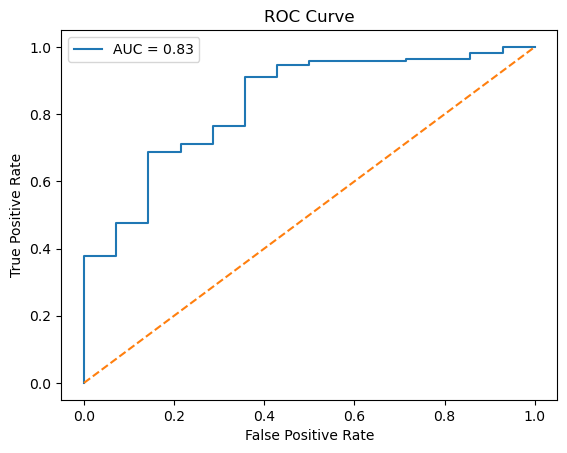

In [250]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Confusion Matrix:
 [[  0  14]
 [  0 170]]


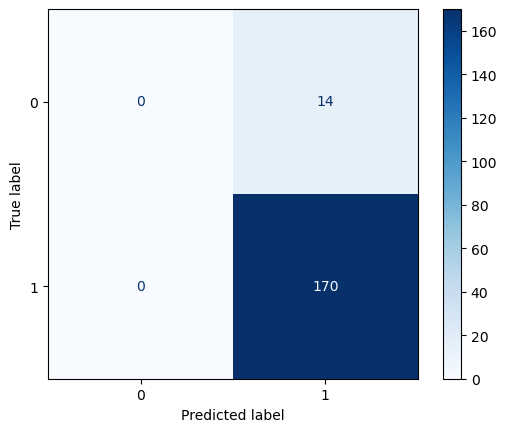

In [251]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

In [252]:
print("\nEnter customer details:\n")

browsing_time = float(input("Browsing Time: "))
clicks = float(input("Clicks: "))
product_views = float(input("Product Views: "))
cart_additions = float(input("Cart Additions: "))
previous_purchases = float(input("Previous Purchases: "))
time_on_product_page = float(input("Time on Product Page: "))
bounce_rate = float(input("Bounce Rate: "))
discount_viewed = float(input("Discount Viewed (0/1): "))

input_data = np.array([[browsing_time, product_views, clicks,cart_additions]])
prediction = model.predict(input_data)[0]

if prediction == 1:
    print("\nCustomer WILL Purchase")
else:
    print("\nCustomer will NOT Purchase")


Enter customer details:



Browsing Time:  300
Clicks:  200
Product Views:  40
Cart Additions:  10
Previous Purchases:  6
Time on Product Page:  200
Bounce Rate:  0.12
Discount Viewed (0/1):  1



Customer WILL Purchase
